In [ ]:
# Copyright 2023 Nico Curti, Gianluca Carlini, and Riccardo Biondi
# Author: Nico Curti
# e-mail: nico.curti2@unibo.it

In [1]:
import numpy as np
import pylab as plt
import networkx as nx
from skimage.morphology import skeletonize_3d
from skimage.measure import marching_cubes
from np_demo import GraphThicknessImageFilter3D

import nibabel.freesurfer.mghformat as mghf # read mgz images

# Topological graph analysis - Brain

Demo of the `GraphThicknessImageFilter` applied for the characterization of the topological graph extracted from a brain volume.

In this demo we will see how we can use the graph filter for the analysis of 3D medical volume.
In particular, we will use a custom 3D brain volume related containing the 3D segmentation of the brain volume, i.e. a standard binary mask produced by software like BrainVisa or other custom algorithms belonging to the neuroscience research field.

Starting from the 3D volume of the brain, we will extract the corresponding internal skeleton and related graph, aiming to analyze it using a standard graph-theory approach.

For the loading and management of the brain volume, we will use the `nibabel` library.
The volume analyzed in this demo was extracted from the OASIS dataset (ref. [here](https://www.oasis-brains.org/)).

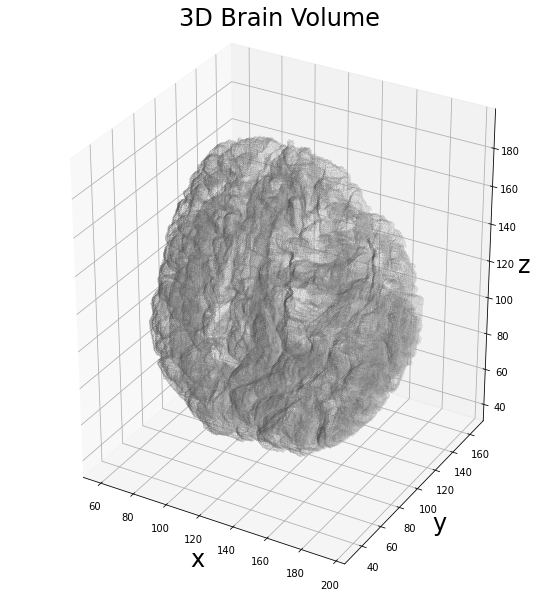

In [2]:
# Read the binary label
vol = mghf.load('samples/aseg.mgz')

# get the volume array
volume = vol.get_fdata()

# binarize the volume
volume = volume != 0

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(volume, 0)

# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the object volume
ptx, pty, ptz = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.05,
                antialiased=False, 
                linewidth=0.0
               )
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Brain Volume', fontsize=24)

The first step in our analysis involves the extraction of the 3D skeleton using the Lee algorithm.
In this way we aim to extract the internal topological structure of the brain shape.

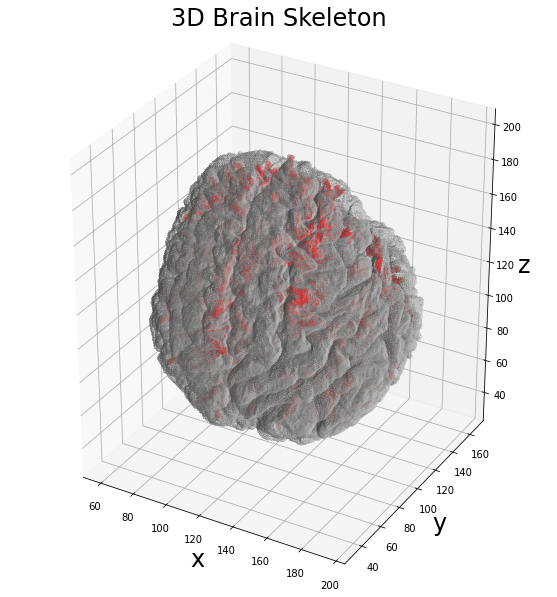

In [3]:
# apply the skleletonization algorithm
skeleton = skeletonize_3d(volume)

# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the skeleton shape
sx, sy, sz = np.where(skeleton)
ax.scatter(sx, sy, sz, color='r', marker='o', s=20, alpha=0.5)
    
# draw the object volume
ptx, pty, ptz = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.1,
                antialiased=False, 
                linewidth=0.0
               )
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Brain Skeleton', fontsize=24)

Now we can apply the graph filter to the obtained skeleton volume to extract the information about the surrounding network.
Since we are interested into the analysis of its shape, we will use the `networkx` library for the storage of the information.

In [41]:
# define the graph extractor to use in the following examples
extractor = GraphThicknessImageFilter3D(surface_min_points=8,
                                        # minimum number of points for the node identification
                                        remove_surface=False
                                        # remove the skeleton surfaces
                                        )

# execute the filter
extractor(skeleton)

# get the list of edges
edges = extractor.GetEdges()

# Since the brain is a complex shape, links between more than 2 nodes
# can happen due to the presence of surfaces in the skeleton volume.
# A simple way to avoid this "issues" is given by filtering the edges
# with a length > 2, creating the graph using ONLY the edge list
# Uncomment the following line if the "remove_surface" is set to True
#edges = list(filter(lambda x : len(x) < 3, edges))

# define the graph
graph = nx.Graph()
# add the list of edges to the graph
graph.add_edges_from(edges)

print('Number of nodes: {:d}'.format(nx.number_of_nodes(graph)))
print('Number of edges: {:d}'.format(nx.number_of_edges(graph)))

Number of nodes: 1008
Number of edges: 1236


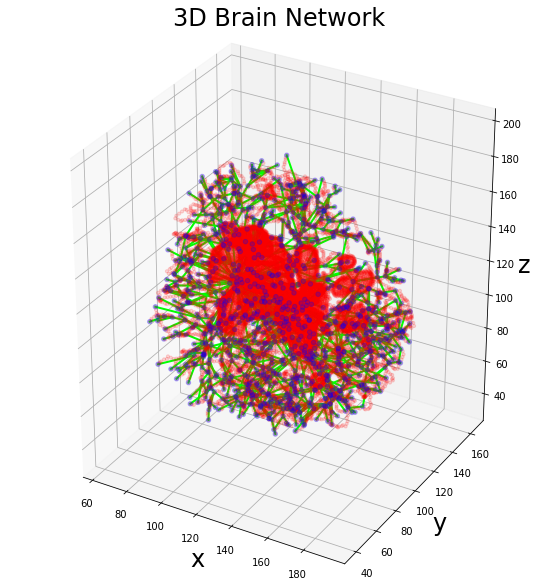

In [30]:
# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the skeleton shape
sx, sy, sz = np.where(skeleton)
ax.scatter(sx, sy, sz, color='r', marker='o', s=10, alpha=0.15)

# plot the nodes as blue dots
ax.scatter(*zip(*graph.nodes()), color='b', marker='o', s=20, alpha=0.25)
    
# plot the edges as lines between vertices
for ex, ey in graph.edges():
    ax.plot(*zip(*(ex, ey)), color='lime', linewidth=2)
    
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Brain Network', fontsize=24)

As expected, the topology of the brain skeleton is quite complex and there are several surfaces generated by the Lee skeletonization algorithm related to the cavities inside the volume.
These cavities produce the skeleton surfaces which lead to the overestimating number of edges produced by the graph algorithm.

Now we can start by the information stored into our graph and try to analyze its volume from a topological point of view.
The first analysis for the characterization of a topological network involves the correlation between the centrality measures extracted by its nodes.
First of all we can take a look at the distributions of the classical centrality measures.

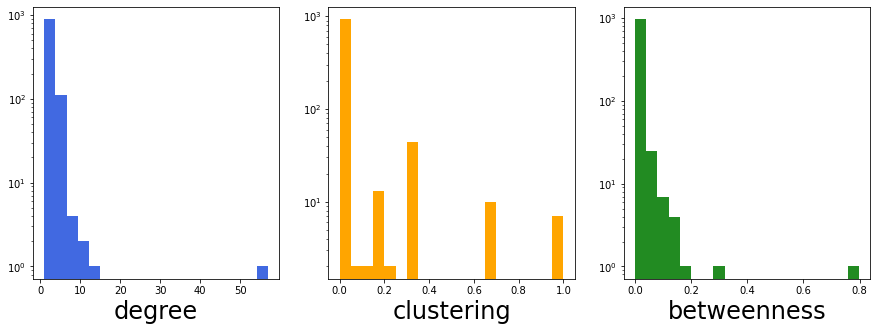

In [40]:
degree = nx.degree(graph)
clustering = nx.clustering(graph)
betweenness = nx.betweenness_centrality(graph)

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
_ = ax1.hist(dict(degree).values(), bins=20, color='royalblue')
_ = ax1.set_xlabel('degree', fontsize=24)
_ = ax1.set_yscale('log')
_ = ax2.hist(dict(clustering).values(), bins=20, color='orange')
_ = ax2.set_xlabel('clustering', fontsize=24)
_ = ax2.set_yscale('log')
_ = ax3.hist(dict(betweenness).values(), bins=20, color='forestgreen')
_ = ax3.set_xlabel('betweenness', fontsize=24)
_ = ax3.set_yscale('log')

The high number of nodes with unitary degree informs us about the tree-like structure of the network. 
A node with degree == 1 is also called *pendant node* and their quantification in a network is informative about the presence of possible redundant information.
A standard approach in graph-analysis, indeed, involves the remotion of these pendant nodes, focusing the attention on the most central ones.

**Note:** Despite the 26-connectivity should represent also the maximum degree obtainable by a node in the graph, due to the skeleton surfaces this limit is removed.
This justify the presence of an outlier in the distribution of the degree, and its height is related to the number of surfaces involved in the skeleton volume.

Furthermore, there is no a clear distribution of the *degree centrality*, as much as for the other two centrality measures.
In particular, the *betweenness centrality* seems to be a classical long-tail distribution, with an high number of nodes with values closed to zero.

Other information can be extracted considering the correlation between these centrality measures.
For example the trend between *degree centrality* and *clustering centrality* is often used for the classification of the graphs in their families (e.g. Barabasi-Albert, Erdos-Renyi, etc.)

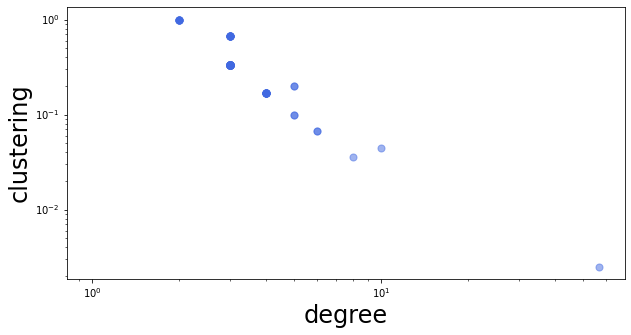

In [38]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
ax.scatter(dict(degree).values(), dict(clustering).values(), 
           marker='o', s=50, color='royalblue',
           alpha=0.5
          )
ax.set_xlabel('degree', fontsize=24)
ax.set_ylabel('clustering', fontsize=24)
ax.set_xscale('log')
ax.set_yscale('log')

The trend between these two centrality measures seems to be a reasonable exponential.
Indeed, this kind of trend can be obtained by tree-like networks or more advanced structures derived by a core Barabasi-Albert graph.
However, for a complete characterization of this topological aspect is mandatory to perform a statistical evaluation on several brain volumes.

Another approach for the characterization of the graph is given by the standard tests provided by the `networkx` library.
An example is given by the community analysis of the graph.

Found 25 Louvain communities


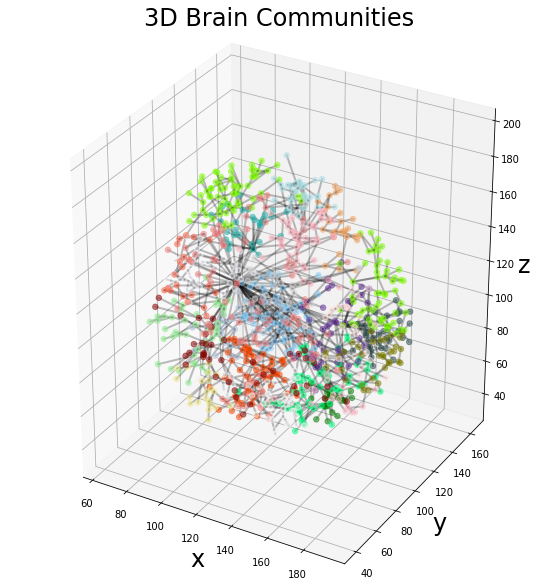

In [66]:
import matplotlib.colors as mcolors

colors = list(mcolors.CSS4_COLORS.keys())
np.random.shuffle(colors)

community = list(nx.community.louvain_communities(graph, seed=42))

print('Found {:d} Louvain communities'.format(len(community)))

# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the skeleton shape
#sx, sy, sz = np.where(skeleton)
#ax.scatter(sx, sy, sz, color='r', marker='o', s=10, alpha=0.15)

# plot the nodes as blue dots
for com, color in zip(community, colors):
    ax.scatter(*zip(*com), color=color, marker='o', s=30, alpha=0.5)
    
# plot the edges as lines between vertices
for ex, ey in graph.edges():
    ax.plot(*zip(*(ex, ey)), color='k', linewidth=2, alpha=0.25)
    
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Brain Communities', fontsize=24)

The communities identified by the Louvain algorithm can be put in relation with the brain anatomical regions or other functional information about the brain in future works.